# EDA Inicial
## Grupo 1

#### Se importan las librerías. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Se importan los datos.

In [3]:
df = pd.read_csv('archivo.csv')
df.head(2)

C:\Users\ricro\AppData\Local\Temp\ipykernel_28080\2106160872.py:1: DtypeWarning: Columns (28,29,40,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('archivo.csv')


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,20250916040734,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,20250916040734,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"


##### Se limpia la variable price.

In [5]:
df["price"] = pd.to_numeric(df["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False),
                            errors="coerce")
# Eliminar filas donde price quedó como NaN
df = df.dropna(subset=["price"])

#### Información de los datos.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76246 entries, 0 to 164212
Data columns (total 80 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            76246 non-null  float64
 1   listing_url                                   76246 non-null  object 
 2   scrape_id                                     76246 non-null  int64  
 3   last_scraped                                  76246 non-null  object 
 4   source                                        76246 non-null  object 
 5   name                                          76246 non-null  object 
 6   description                                   74622 non-null  object 
 7   neighborhood_overview                         40226 non-null  object 
 8   picture_url                                   76246 non-null  object 
 9   host_id                                       76246 non-null  int

#### Se eliminarán las variables que no son de interés para la regresión.

In [7]:
columnas_eliminar = ['id', 'listing_url', 'scrape_id','name', 'description', 'neighborhood_overview', 'picture_url',
                     'host_id', 'host_url', 'host_name', 'host_about', 'host_thumbnail_url', 'host_picture_url']

df = df.drop(columns = columnas_eliminar)

#### Se analizará el resto de las variables para quitar aquellas de alta dimensión.

In [8]:
# Selección de columnas no numéricas.
columnas_no_numericas = df.select_dtypes(include=["object", "category"]).columns

# Permite contar la cantidad de catergorías.
conteo_categorias = df[columnas_no_numericas].nunique(dropna=True)

# Se convierte a DataFrame.
resumen_categorias = (
    conteo_categorias
    .sort_values(ascending=False)
    .reset_index()
)
resumen_categorias.columns = ["variable", "cantidad_categorias"]

# Se muestra el resumen de categorías.
resumen_categorias

,variable,cantidad_categorias
0,amenities,67213
1,license,38267
2,host_since,5407
3,first_review,4634
4,last_review,2111
5,host_location,1768
6,host_neighbourhood,1749
7,neighbourhood_cleansed,393
8,host_acceptance_rate,101
9,property_type,94


#### Se eliminan las variables de alta dimensión > 10.

In [9]:
df = df.drop(columns = resumen_categorias[resumen_categorias['cantidad_categorias'] > 10]['variable'])
df.head(2)

,last_scraped,source,host_response_time,host_is_superhost,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,2025-09-17,city scrape,within a few hours,t,1.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,...,4.82,4.73,4.79,f,1,1,0,0,3.52,"Austin, Texas"
1,2025-09-17,city scrape,within an hour,t,1.0,2.0,"['email', 'phone']",t,t,Neighborhood highlights,...,4.98,4.97,4.88,t,1,1,0,0,1.98,"Austin, Texas"


#### Visualización de variables categóricas en boxplots y en gráficos de barras.

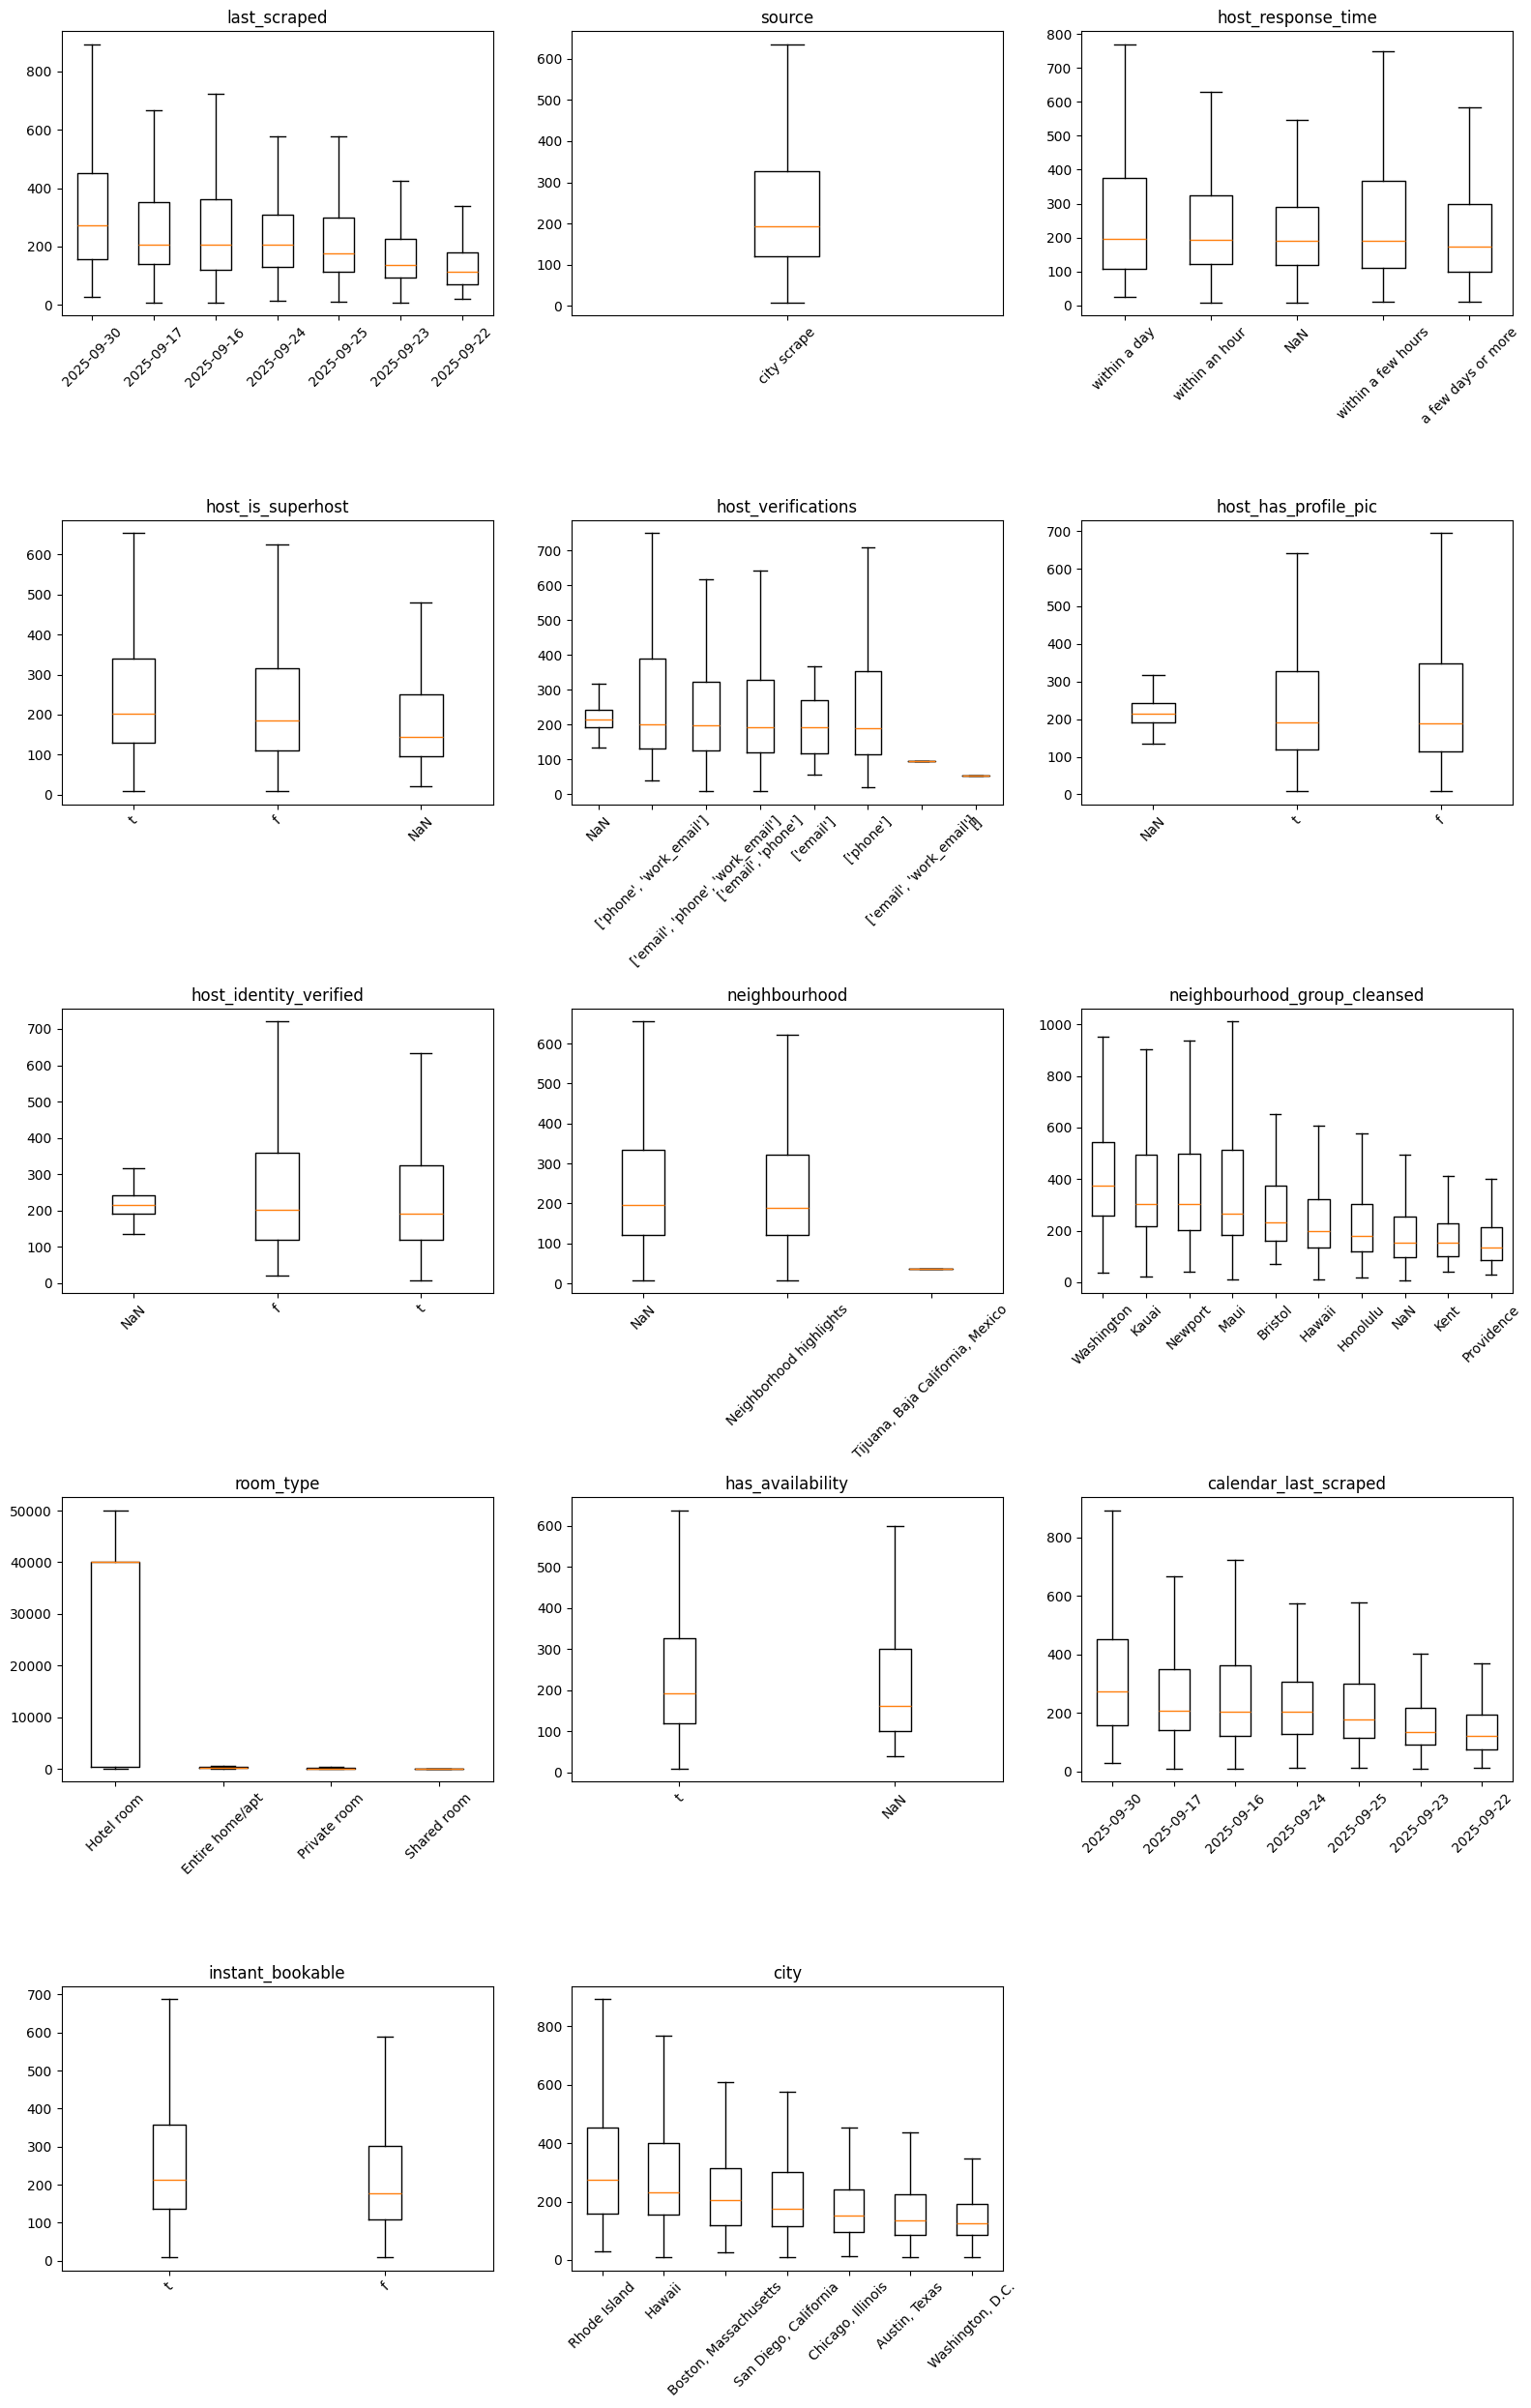

In [13]:
# Selección de columnas no numéricas.
columnas_no_numericas = df.select_dtypes(include=["object", "category"]).columns

# Número de columnas y filas que se usarán, además se agrupan las categorías menos comunes.
cols = 3
rows = int(np.ceil(len(columnas_no_numericas) / cols))
top_k = 10

# Se establece la figura y los ejes.
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = np.array(axes).ravel()

# Se grafican las variables cualitativas.
for i, col in enumerate(columnas_no_numericas):
    sub = df[[col, 'price']].copy()
    sub[col] = sub[col].astype('object').fillna('NaN')

    # Se agrupan categorías poco comunes.
    top = sub[col].value_counts().head(top_k).index
    sub[col] = np.where(sub[col].isin(top), sub[col], 'OTROS')

    # ordenar categorías por mediana del target (opcional pero útil)
    order = sub.groupby(col)['price'].median().sort_values(ascending=False).index.tolist()

    # Se grafica el Boxplot.
    data = [sub.loc[sub[col] == c, 'price'].dropna().values for c in order]
    axes[i].boxplot(data, tick_labels=order, showfliers=False)
    axes[i].set_title(col)
    axes[i].tick_params(axis = 'x', rotation=45)

# Se quitan los ejes que no se usarán.
for j in range(len(columnas_no_numericas), len(axes)):
    axes[j].axis('off')

# Se ajustan las etiquetas y se visualiza la figura.
plt.tight_layout()
plt.show()

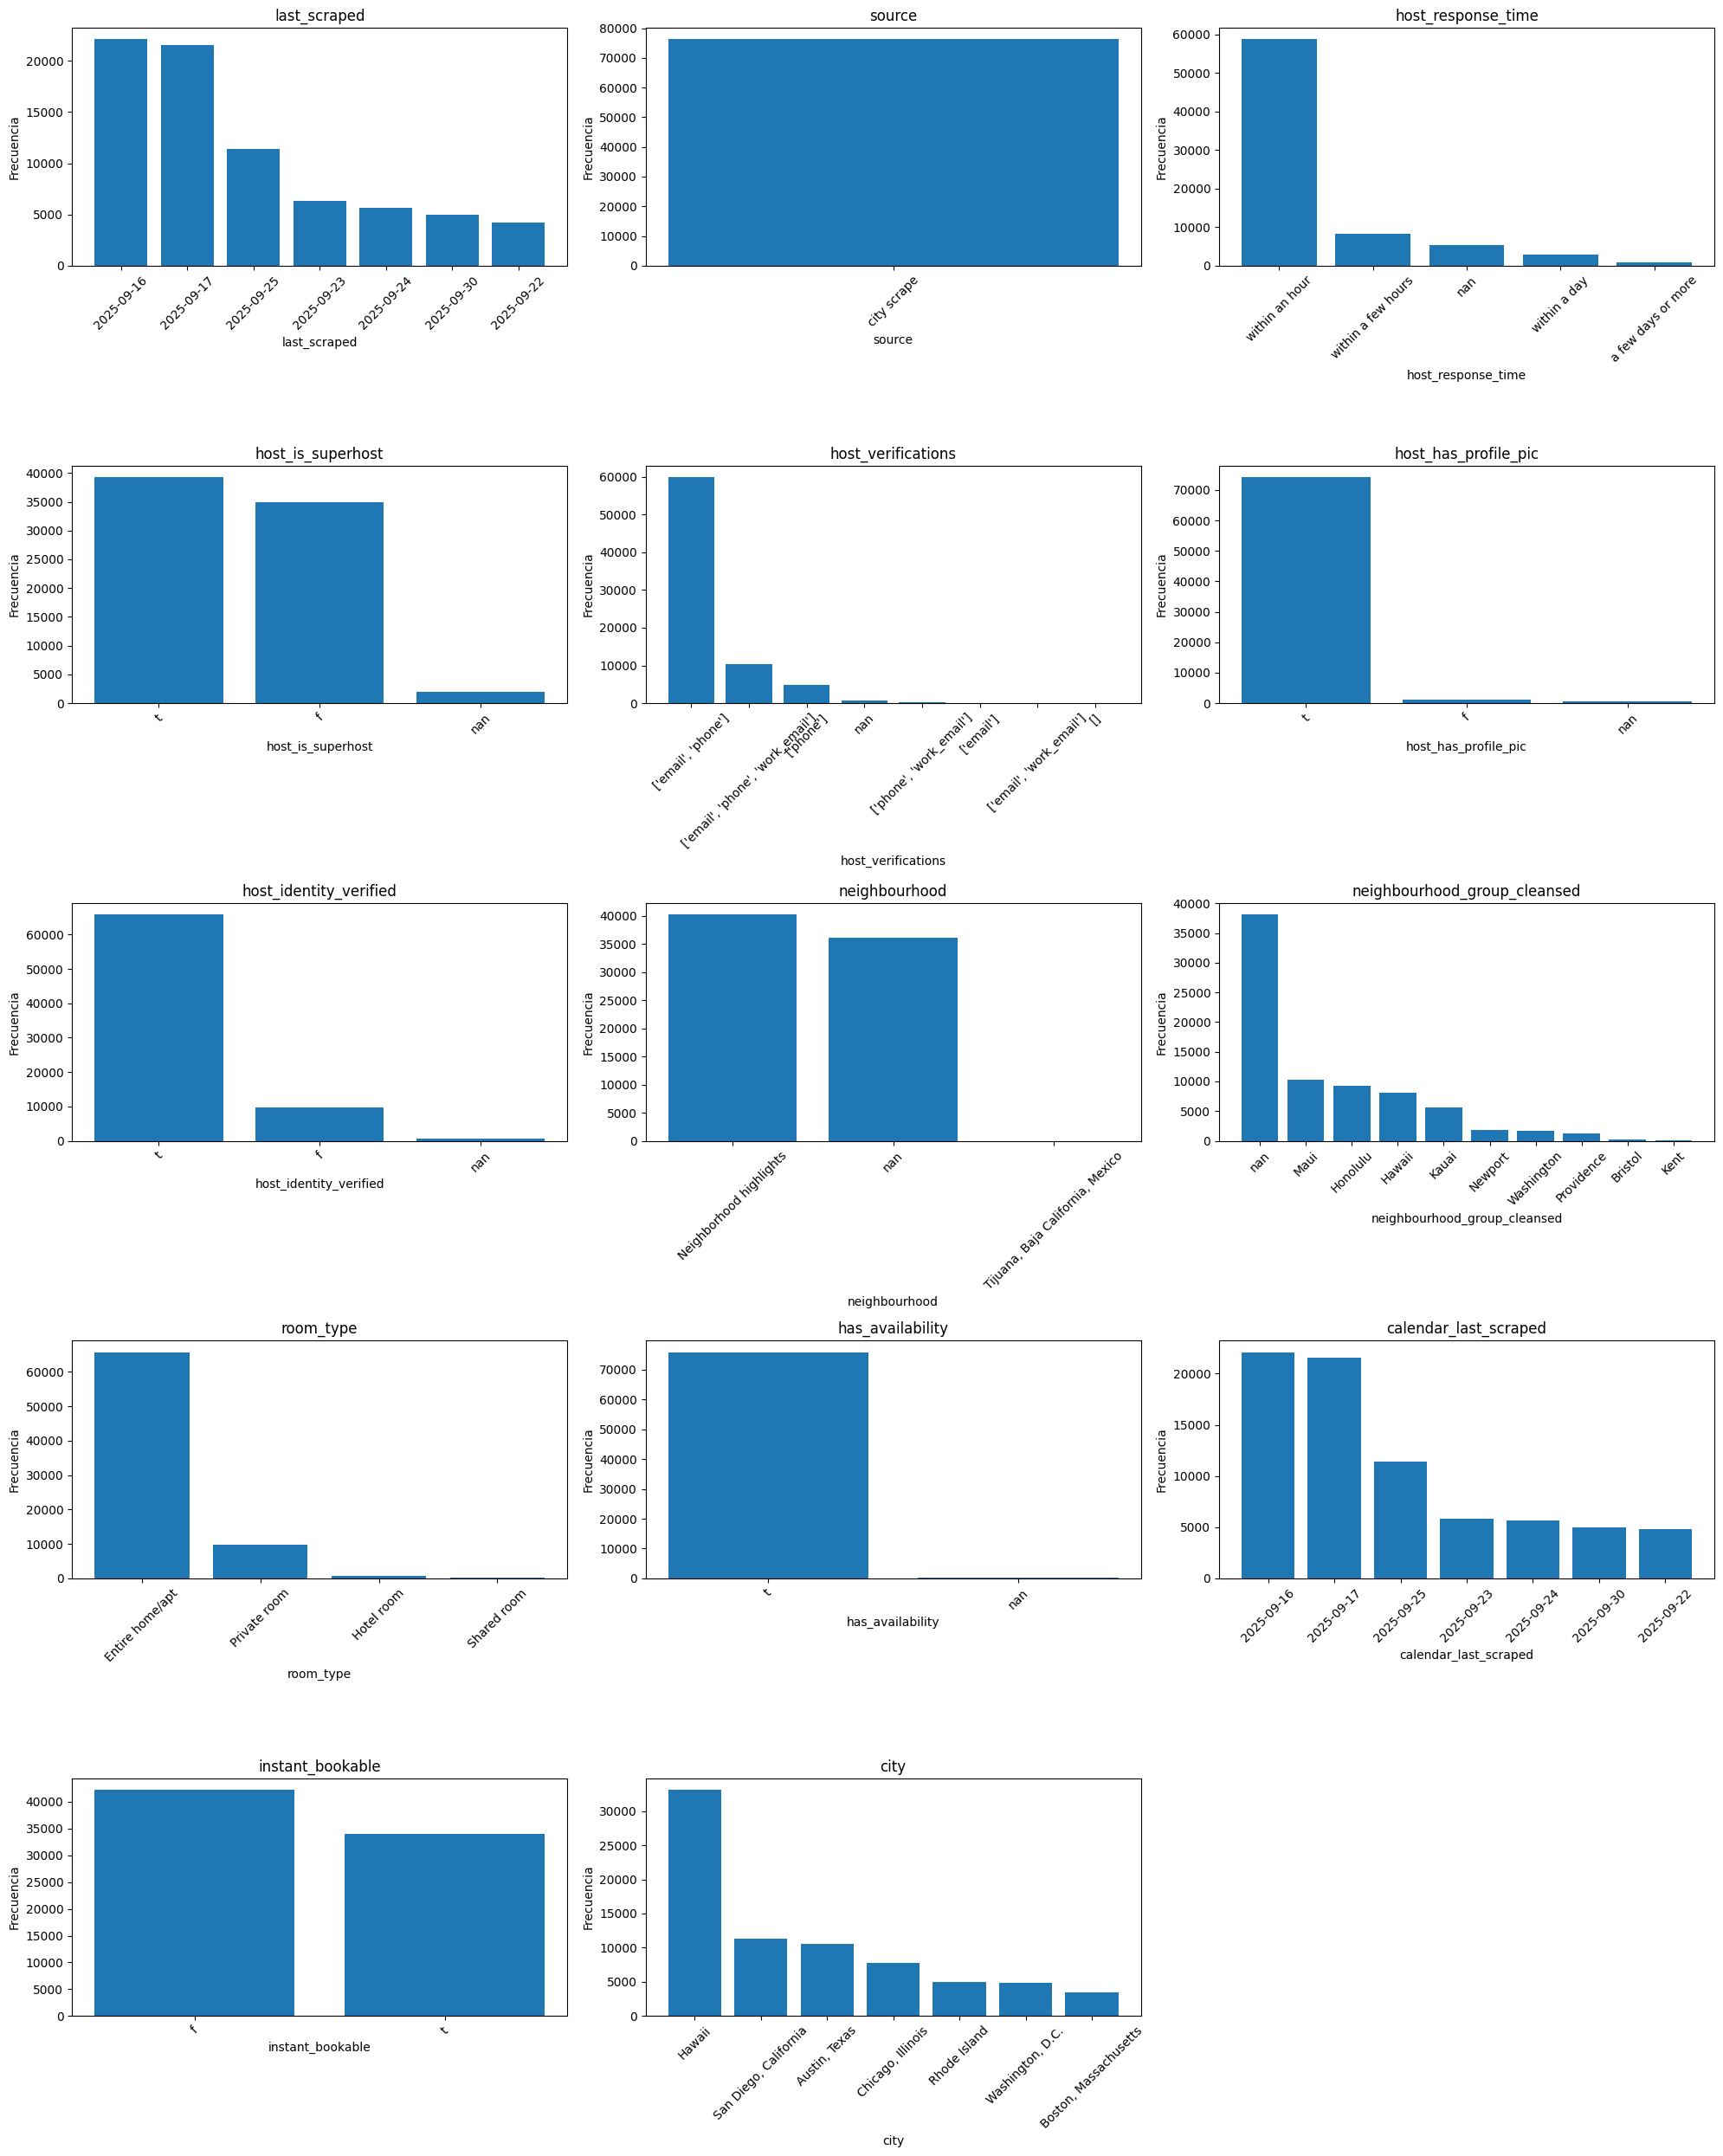

In [14]:
# Selección de columnas no numéricas.
columnas_no_numericas = df.select_dtypes(include=["object", "category"]).columns

cols = 3
rows = int(np.ceil(len(columnas_no_numericas) / cols))
top_k = 15

# Se establece la figura y los ejes.
figsize = (20, 25)
fig, axes = plt.subplots(rows, cols, figsize=figsize)
axes = np.array(axes).reshape(-1)

# Se grafican las variables cualitativas.
for i, col in enumerate(columnas_no_numericas):
    vc = df[col].value_counts(dropna=False)

    # Parte donde se limitan la cantidad de variables.
    if len(vc) > top_k:
        top = vc.iloc[:top_k]
        otros = vc.iloc[top_k:].sum()
        vc_plot = top.copy()
        vc_plot.loc['OTRO'] = otros
    else:
        vc_plot = vc

    axes[i].bar(vc_plot.index.astype(str), vc_plot.values)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

# Se quitan los ejes que no se usarán.
for j in range(len(columnas_no_numericas), len(axes)):
    axes[j].axis('off')

# Se ajustan las etiquetas y se visualiza la figura.
plt.tight_layout()
plt.show()

Se obserba que las variables instant_bookable, city, host_verifications, host_identity_verified, host_is_superhost. Esto porque estas variables parecen afectar a la variable objetivo de forma idéntica, por lo cual no será relevante.

In [15]:
df = df.drop(columns=['instant_bookable', 'city', 'host_verifications', 'host_identity_verified', 'has_availability'])

Observemos la cantidad de nulos.

In [16]:
# Se genera el resumen de la cantidad de faltantes y el porcentaje de estos.
total_filas = len(df)
faltantes_resumen = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje_faltantes": (df.isna().sum() / total_filas) * 100
})

# Se ordena por el porcentaje y se redondea.
faltantes_resumen = faltantes_resumen.sort_values(by="porcentaje_faltantes", ascending=False)
faltantes_resumen["porcentaje_faltantes"] = faltantes_resumen["porcentaje_faltantes"].round(2)

# Se muestra el resumen.
faltantes_resumen

,faltantes,porcentaje_faltantes
calendar_updated,76246,100.00
neighbourhood_group_cleansed,38121,50.00
neighbourhood,36020,47.24
review_scores_location,13417,17.60
review_scores_cleanliness,13417,17.60
review_scores_checkin,13417,17.60
review_scores_accuracy,13417,17.60
review_scores_value,13417,17.60
review_scores_communication,13417,17.60
reviews_per_month,13413,17.59


#### Se eliminarán aquellas que tengan un valor superior al 20% de faltantes.

In [17]:
df = df.drop(columns = list(faltantes_resumen[faltantes_resumen['porcentaje_faltantes'] > 20].index))
df.head(2)

,last_scraped,source,host_response_time,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,latitude,longitude,room_type,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2025-09-17,city scrape,within a few hours,t,1.0,2.0,t,30.26057,-97.73441,Entire home/apt,...,4.86,4.90,4.82,4.73,4.79,1,1,0,0,3.52
1,2025-09-17,city scrape,within an hour,t,1.0,2.0,t,30.26034,-97.76487,Entire home/apt,...,4.96,4.99,4.98,4.97,4.88,1,1,0,0,1.98


#### Observemos una descripción estadística de lo datos numéricos.

In [18]:
df.describe()

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,75619.000000,75619.000000,76246.000000,76246.000000,76246.000000,76232.000000,76125.000000,76166.000000,76246.000000,76246.000000,...,62829.000000,62829.000000,62829.000000,62829.000000,62829.000000,76246.000000,76246.000000,76246.000000,76246.000000,62833.000000
mean,188.223647,275.569619,29.617686,-121.172951,4.841369,1.617110,1.809537,2.637489,750.509220,9.414566,...,4.790816,4.870193,4.866532,4.836618,4.709758,54.556737,52.196233,1.733284,0.092136,1.577088
std,668.556651,988.185870,8.520383,34.074986,2.998857,0.980943,1.371286,2.109314,4250.606945,22.387397,...,0.331235,0.287254,0.299240,0.278100,0.365220,113.051874,112.982782,7.109996,2.115833,1.732988
min,1.000000,1.000000,18.989648,-159.716528,1.000000,0.000000,0.000000,0.000000,8.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.000000,2.000000,21.274370,-156.679234,2.000000,1.000000,1.000000,1.000000,120.000000,1.000000,...,4.730000,4.860000,4.860000,4.800000,4.640000,1.000000,1.000000,0.000000,0.000000,0.320000
50%,8.000000,11.000000,30.266685,-117.201440,4.000000,1.000000,1.000000,2.000000,193.000000,2.000000,...,4.880000,4.950000,4.960000,4.920000,4.790000,5.000000,3.000000,0.000000,0.000000,1.020000
75%,66.000000,97.000000,38.905197,-87.682454,6.000000,2.000000,2.000000,3.000000,326.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,4.910000,41.000000,37.000000,0.000000,0.000000,2.360000
max,5472.000000,9715.000000,42.391844,-70.996000,16.000000,20.000000,57.000000,132.000000,50123.000000,720.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,612.000000,612.000000,89.000000,60.000000,61.590000


#### Los faltantes de beds, bathrooms y bedrooms se tratarán usando la media de los datos. En el caso de las demás columnas de faltantes se eliminarán las filas que tengan estos, ya que no suponen más del 5% de datos, al tener muchos registros no nos preocupamos por poca variabilidad de datos.

In [19]:
# Columnas donde imputaremos con la media
cols_media = ['beds', 'bathrooms', 'bedrooms']

# Imputación con la media
for col in cols_media:
    media_col = df[col].mean()
    df[col] = df[col].fillna(media_col)

# Eliminando filas con faltantes.
otras_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_listings_count', 'host_total_listings_count', 'minimum_maximum_nights',
              'maximum_maximum_nights', 'maximum_minimum_nights', 'minimum_minimum_nights']
df = df.dropna(subset=otras_cols)

#### Se convierten las categóricas a numéricas.

In [20]:
columnas_categoricas = df.select_dtypes(include=["object", "category"]).columns

# Aplicar get_dummies
df = pd.get_dummies(
    df,
    columns=columnas_categoricas,
    drop_first=False,              # True si quieres evitar multicolinealidad
    dtype=int                      # para que las columnas queden como 0 y 1
)

#### Se exporta el DataFrame resultante.

In [21]:
df.to_csv('datos_limpios.csv', index_label= False)